# Korad KA3005P voltage sweep

This notebook controls the KA3005P (also RND 320-KA3005P) over serial using the `Ka3005P` pyserial class and plots measured output with Matplotlib.

Install the dependencies if needed: `pip install pyserial matplotlib numpy`.

**Hardware caution:** Check the connected load, wiring, and voltage/current limits before running the sweep. The output is explicitly enabled by the run cell and automatically switched off when it finishes or raises an error. Keep the power supply supervised while the notebook is running.

In [7]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))

import Skripte

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from Skripte.Ka3005P import Ka3005P

## Connect to device

Open the connection, set output to 0 V

In [9]:
power_supply = Ka3005P()

power_supply.connect("COM24")
print("Device:", power_supply.get_version())

power_supply.set_voltage(0.0)
power_supply.set_current(5.0)
power_supply.set_on_off(True)

print(f"Voltage: {power_supply.get_voltage():.3f} V, Current: {power_supply.get_current():.3f} A")

Ka3005P, connect with port COM24
Device: KORADKA3005PV2.0 
Voltage: 0.000 V, Current: 0.001 A


## Run a voltage sweep

In [10]:
measured_voltage, measured_current = power_supply.voltage_sweep(np.arange(0.0, 12.1, 0.5), 0.2)

power_supply.set_on_off(False)

print("Voltage sweep complete; output switched off and serial port disconnected.")

Voltage sweep complete; output switched off and serial port disconnected.


In [11]:
power_supply.disconnect()

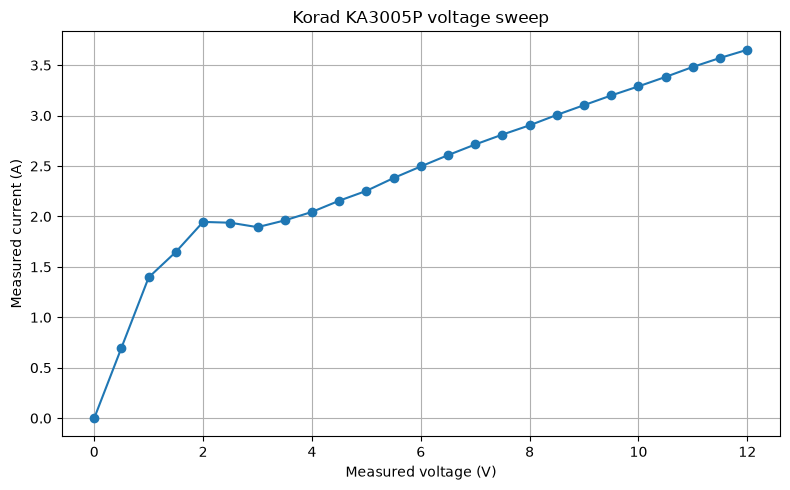

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(measured_voltage, measured_current, "o-")
plt.xlabel("Measured voltage (V)")
plt.ylabel("Measured current (A)")
plt.title("Korad KA3005P voltage sweep")
plt.grid(True)
plt.tight_layout()
plt.show()